In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# !pip uninstall -y transformers
# !pip install transformers==4.54.1 datasets --quiet
!pip install --upgrade transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 44.0 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.8/558.8 kB 33.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.33.2
    Uninstalling huggingface-hub-0.33.2:
      Successfully uninstalled huggingface-hub-0.33.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.53.0
    Uninstalling transformers-4.53.0:
      Successfully uninstalled transformers-4.53.0

[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [4]:
!pip install --upgrade tf-keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 16.8 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.8/644.8 MB 727.5 kB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 52.6 MB/s eta 0:00:0000:01:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 55.5 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:
      Successfully uninstalled tensorboard-2.18.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.18.1
    Uninstalling tensorflow-2.18.1:
      Successfully uninstalled tensorflow-2.18.1
  Attempting uninstall: tf-keras
    Found existing installation: tf_keras 2.18.0
    Uninstalling tf_keras-2.18.0:
      Successful

In [5]:
!pip install -q ipywidgets --upgrade


[notice] A new release of pip is available: 23.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [6]:
pip install --upgrade pip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.0 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 23.0.1
    Uninstalling pip-23.0.1:
      Successfully uninstalled pip-23.0.1
Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install -q tensorflow-cpu

Note: you may need to restart the kernel to use updated packages.


In [7]:
import transformers
print(transformers.__version__)

4.54.1


In [10]:
# from tqdm.auto import tqdm
# from time import sleep

# for i in tqdm(range(5)):
#     sleep(1)

# TSA Inference

We shall stick to using the CSV that contains extracted text from **Google's Cloud Vision OCR API**

## DistillRoBERTa Inference

## Loading the Model

In [11]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# loading the tokenizer and model from HF transformers
tokenizer = AutoTokenizer.from_pretrained('distilroberta-base')

# num_labels = 3 for Postive, Neutral, and Negative sentiment classes
model = AutoModelForSequenceClassification.from_pretrained('distilroberta-base', num_labels=3)

/usr/local/lib/python3.10/site-packages/torch_xla/__init__.py:251: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
!pip install -q datasets

## Loading and Tokenizing the Dataset

In [28]:
filepath = "/kaggle/input/ocr-gsv-pytesseract/gcv-ocr.csv"

df = pd.read_csv(filepath)
df = df[df["text-detected"]!=0]

# print(df["OCR"][0])
# print(len(df)) # 2749

df[["OCR","sentiment"]].to_csv("temp_data.csv", index=False)

In [29]:
root = "/kaggle/working/temp_data.csv"

In [30]:
from datasets import load_dataset
# loading the dataset for sentiment analysis on financial data
# dataset = load_dataset("FinanceInc/auditor_sentiment")


# Load your CSV (replace with your actual file path)
dataset = load_dataset("csv", data_files=root)

# View a sample
print(dataset['train'][0])


# let's take a look at the first entry to get a feel for the data
# dataset['train'][1]

Generating train split: 0 examples [00:00, ? examples/s]

{'OCR': 'STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT', 'sentiment': 'negative'}


In [31]:
dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 2749
    })
})

In [42]:
from sklearn.model_selection import train_test_split
from datasets import ClassLabel
import datasets

# First define the label names from your dataset
label_names = dataset['train'].unique('sentiment')
label_names.sort()

# Cast the sentiment column to ClassLabel
dataset = dataset.cast_column("sentiment", ClassLabel(names=label_names))

# Now you can stratify
split_dataset = dataset['train'].train_test_split(test_size=0.2, stratify_by_column="sentiment")

Casting the dataset:   0%|          | 0/2749 [00:00<?, ? examples/s]

In [43]:
split_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 2199
    })
    test: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 550
    })
})

In [44]:
type(split)

datasets.dataset_dict.DatasetDict

In [45]:
split = split_dataset['train'].train_test_split(test_size=0.1, stratify_by_column="sentiment")

final_dataset = datasets.dataset_dict.DatasetDict({
    'train': split['train'],
    'validation': split['test'],
    'test': split_dataset['test']
})

final_dataset

DatasetDict({
    train: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 1979
    })
    validation: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 220
    })
    test: Dataset({
        features: ['OCR', 'sentiment'],
        num_rows: 550
    })
})

In [46]:
# defining a function to tokenize the sentences
def tokenize_function(example):
    return tokenizer(
        example['OCR'],
        # padding sentences to the maximum length for consistent input size
        padding='max_length',
        # truncating sentences to fit within the model's expected input length
        truncation=True,
        # returning attention masks to let the model know which tokens are padding
        return_attention_mask=True
    )

# applying the tokenization function to the entire dataset in batches
tokenized_dataset = final_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/2749 [00:00<?, ? examples/s]

## Preparing for Training

In [47]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np

# converting the tokenized train dataset to a pandas DataFrame
df_train = tokenized_dataset['train'].to_pandas()

# extracting input_ids, attention mask, and label from the DataFrame and converting to numpy array
X_train_inputs = np.array(list(df_train['input_ids']))
X_train_attention = np.array(list(df_train['attention_mask']))
y_train = df_train['sentiment']

# converting to tensors
train_inputs = torch.tensor(X_train_inputs)
train_attention = torch.tensor(X_train_attention)
train_labels = torch.tensor(y_train.values)

# creating a TensorDataset from inputs, attention masks, and labels
train_data = TensorDataset(train_inputs, train_attention, train_labels)

# creating a DataLoader for batching the train data
train_dataloader = DataLoader(train_data, batch_size=16, shuffle=True) # Step 4: Evaluating the Model

## Training the Model

In [49]:
# from transformers import AdamW
from torch.optim import AdamW

# set up the optimizer
optimizer = AdamW(model.parameters(), lr=5e-5)

# put the model on device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
           

In [50]:
epochs = 3
for epoch in tqdm(range(epochs)):
    model.train()
    total_loss = 0
    for batch in train_dataloader:
        b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]
        # resetting gradients before backpropagation
        model.zero_grad()
        # performing a forward pass to calculate outputs
        outputs = model(b_input_ids, attention_mask=b_attention_mask, labels=b_labels)
        # calculating the loss 
        loss = outputs.loss
        total_loss += loss.item()
        # backpropagating the loss to compute gradients
        loss.backward()
        # updating model parameters using the computed gradients
        optimizer.step()
    avg_train_loss = total_loss / len(train_dataloader)
    print(f"Epoch {epoch + 1}, Average Training Loss: {avg_train_loss:.4f}")

/usr/local/lib/python3.10/site-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


Epoch 1, Average Training Loss: 0.5123
Epoch 2, Average Training Loss: 0.2336
Epoch 3, Average Training Loss: 0.1468


## Making predictions

In [53]:
# converting the tokenized test dataset to a pandas DataFrame
df_test = tokenized_dataset['train'].to_pandas()

X_test_inputs = np.array(list(df_test['input_ids']))
X_test_attention = np.array(list(df_test['attention_mask']))
y_test = df_test['sentiment']

# converting input_ids to tensor
test_inputs = torch.tensor(X_test_inputs)
test_attention = torch.tensor(X_test_attention)
test_labels = torch.tensor(y_test.values)

# creating a TensorDataset & DataLoader from inputs, attention masks, and labels
test_data = TensorDataset(test_inputs, test_attention, test_labels)
test_dataloader = DataLoader(test_data, batch_size=16)

In [55]:
def get_predictions(model, dataloader):
    # setting the model to evaluation mode
    model.eval()
    predictions = []
    true_labels = []
    with torch.no_grad():
        for batch in dataloader:
            b_input_ids, b_attention_mask, b_labels = [t.to(device) for t in batch]
            # forward pass to obtain model outputs
            outputs = model(b_input_ids, attention_mask=b_attention_mask)
            # extracting logits
            logits = outputs.logits
            # predicting the class with the highest score
            predicted_class = torch.argmax(logits, dim=1)
            # storing predictions and true labels for the current batch
            predictions.extend(predicted_class.cpu().numpy())
            true_labels.extend(b_labels.cpu().numpy())
    return predictions, true_labels

baseline_predictions, true_labels = get_predictions(model, test_dataloader)

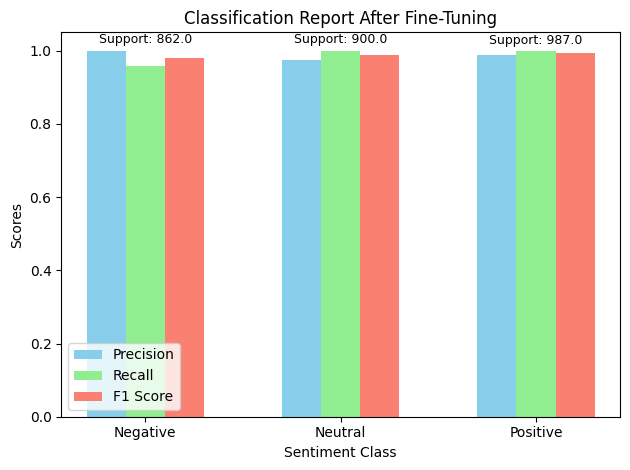

In [57]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np

report = classification_report(true_labels, baseline_predictions, target_names=['Negative', 'Neutral', 'Positive'], output_dict=True)

labels = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[label]['precision'] for label in labels]
recall = [report[label]['recall'] for label in labels]
f1_score = [report[label]['f1-score'] for label in labels]
support = [report[label]['support'] for label in labels]

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots()
rects1 = ax.bar(x - width, precision, width, label='Precision', color='skyblue')
rects2 = ax.bar(x, recall, width, label='Recall', color='lightgreen')
rects3 = ax.bar(x + width, f1_score, width, label='F1 Score', color='salmon')

ax.set_xlabel('Sentiment Class')
ax.set_ylabel('Scores')
ax.set_title('Classification Report After Fine-Tuning')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

for i in range(len(support)):
    ax.text(i, max(precision[i], recall[i], f1_score[i]) + 0.02, f'Support: {support[i]}', ha='center', fontsize=9)

ax.grid(False)

fig.tight_layout()
plt.show()

In [60]:
print(report['accuracy'])

0.9865405602037104


In [52]:
tokenized_dataset.keys()

dict_keys(['train'])

In [7]:
def preprocess(df):
    df = df[df['text-detected']!=0]

In [8]:
df = pd.read_csv("/kaggle/input/ocr-gsv-pytesseract/gcv-ocr.csv")
df.head()

,filename,filepath,text-detected,OCR,coordinates,sentiment
0,negative_001.jpg,/kaggle/input/musait/basket/negative_001.jpg,1,STOP WAR\nUKRAINE\nIN\nСлава Україні!\nMAKE\nNOT,"[{'x': 513, 'y': 24}, {'x': 975, 'y': 24}, {'x...",negative
1,negative_002.jpg,/kaggle/input/musait/basket/negative_002.jpg,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",negative
2,negative_003.jpg,/kaggle/input/musait/basket/negative_003.jpg,0,NaN,[],negative
3,negative_004.jpg,/kaggle/input/musait/basket/negative_004.jpg,0,NaN,[],negative
4,negative_005.jpg,/kaggle/input/musait/basket/negative_005.jpg,1,HUNDREDS\nKILLED IN\nUKRAINE\n>NEWS\nNIGHTLY AT 6,"[{'x': 20, 'y': 61}, {'x': 508, 'y': 61}, {'x'...",negative


In [9]:
def clean_ocr_text(text):
    text = text.replace("\n", " ").strip() # Removes '\n' characters
    text = ' '.join(text.split())  # remove excess spaces
    return text

In [10]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TextClassificationPipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

# Load your dataset
df = pd.read_csv(filepath) 
df_filtered = df[df['text-detected']!=0]
# print(len(df))

texts = df_filtered['OCR'].tolist()
true_labels = df_filtered['sentiment'].tolist()

texts_clean = [clean_ocr_text(text) for text in texts]

/usr/local/lib/python3.10/site-packages/torch_xla/__init__.py:251: UserWarning: `tensorflow` can conflict with `torch-xla`. Prefer `tensorflow-cpu` when using PyTorch/XLA. To silence this warning, `pip uninstall -y tensorflow && pip install tensorflow-cpu`. If you are in a notebook environment such as Colab or Kaggle, restart your notebook runtime afterwards.
  warnings.warn(
E0000 00:00:1753978307.105456      10 common_lib.cc:612] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:230


In [11]:
# SAMPLE Reproducible code for all the models listed below
model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
pipeline = TextClassificationPipeline(model=model, tokenizer=tokenizer, top_k=None, device=0)

preds = pipeline(texts, truncation=True, max_length=512)

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Device set to use cpu
/usr/local/lib/python3.10/site-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

In [12]:
# pred_labels = [int(p['label'].split('_')[-1]) if 'label' in p else p['score'].argmax() for p in preds]  # adjust if needed
print(preds[0])
# print("Accuracy:", accuracy_score(labels, pred_labels))

[{'label': 'LABEL_0', 'score': 0.6321016550064087}, {'label': 'LABEL_1', 'score': 0.3352769613265991}, {'label': 'LABEL_2', 'score': 0.032621365040540695}]


In [13]:
pred_labels = []


id2label = {
        "LABEL_0": "negative",
        "LABEL_1": "neutral",
        "LABEL_2": "positive"
}


for p in preds:
    max_pred = max(p, key=lambda x: x['score'])
    best_label = max_pred['label']
    # best_score = max_pred['score']
    pred_labels+=[id2label[best_label]]

print("Accuracy:", accuracy_score(true_labels, pred_labels))

Accuracy: 0.5958530374681702


In [14]:
len(preds)

2749

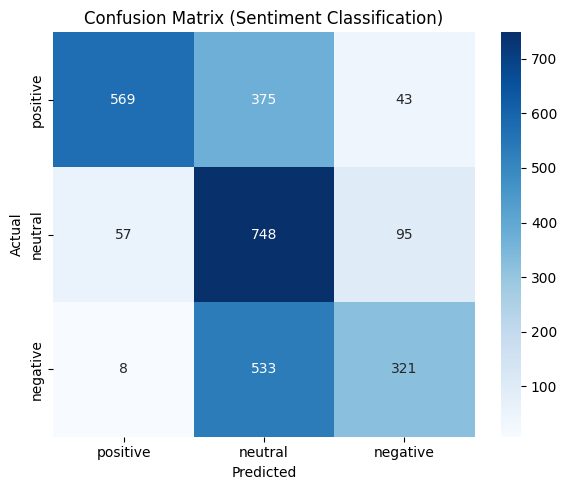

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

labels = ["positive", "neutral", "negative"]

# Compute the confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=labels)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Sentiment Classification)")
plt.tight_layout()
plt.show()

In [16]:
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# print("Confusion Matrix:")
# print(confusion_matrix(true_labels, pred_labels, labels=["positive", "neutral", "negative"]))

print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, labels=["positive", "neutral", "negative"]))


Classification Report:
              precision    recall  f1-score   support

    positive       0.90      0.58      0.70       987
     neutral       0.45      0.83      0.59       900
    negative       0.70      0.37      0.49       862

    accuracy                           0.60      2749
   macro avg       0.68      0.59      0.59      2749
weighted avg       0.69      0.60      0.60      2749



# TSA

## General Setup

In [17]:
pip install transformers datasets scikit-learn pandas torch accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.8/494.8 kB 9.9 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 10.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 13.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 198.3/198.3 kB 17.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.9/222.9 kB 18.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.1/326.1 kB 22.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.6/241.6 kB 20.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.5.1
    Uninstalling fsspec-2025.5.1:
      Successfully uninstalled fsspec-2025.5.1
  Attempting uni

## Load and preprocess data

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load CSV
df = pd.read_csv(filepath)
df_filtered = df[df['text-detected']!=0]
print(len(df_filtered))

texts = df_filtered['OCR'].tolist()
true_labels = df_filtered['sentiment'].tolist()

texts_clean = [clean_ocr_text(text) for text in texts]

# Encode labels
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {v: k for k, v in label2id.items()}
df_filtered['label'] = df_filtered['sentiment'].map(label2id)
# df_filtered.loc[:, 'label'] = df_filtered['sentiment'].map(label2id)

# Train/val/test split
train_df, temp_df = train_test_split(df_filtered, test_size=0.3, stratify=df_filtered['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

2749


/tmp/ipykernel_10/2577487464.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['label'] = df_filtered['sentiment'].map(label2id)


In [19]:
train_df.head()

,filename,filepath,text-detected,OCR,coordinates,sentiment,label
1805,neutral_899.jpg,/kaggle/input/musait/basket/neutral_899.jpg,1,TEDED\nWHAT IS\nDEJA VU?,"[{'x': 343, 'y': 73}, {'x': 1246, 'y': 73}, {'...",neutral,1
576,negative_577.jpg,/kaggle/input/musait/basket/negative_577.jpg,1,SAD TRUTH\n1820\nHELP!\n@successpictures\n2020...,"[{'x': 28, 'y': 31}, {'x': 499, 'y': 31}, {'x'...",negative,0
1283,neutral_377.jpg,/kaggle/input/musait/basket/neutral_377.jpg,1,"Someone: So, tell me\nmore about you?\nMe tryi...","[{'x': 18, 'y': 51}, {'x': 675, 'y': 51}, {'x'...",neutral,1
711,negative_712.jpg,/kaggle/input/musait/basket/negative_712.jpg,1,British Red Cros\nNATURAL DISASTERS:\nEARTHQUA...,"[{'x': 11, 'y': 7}, {'x': 255, 'y': 7}, {'x': ...",negative,0
2366,positive_491.jpg,/kaggle/input/musait/basket/positive_491.jpg,1,Every school\nshould have an\norganic garden t...,"[{'x': 291, 'y': 223}, {'x': 798, 'y': 223}, {...",positive,2


In [20]:
df_filtered['label']

0       0
1       0
4       0
5       0
6       0
       ..
2870    2
2871    2
2872    2
2873    2
2874    2
Name: label, Length: 2749, dtype: int64

## General Model Training Template

In [21]:
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
import numpy as np
from sklearn.metrics import accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

def train_model(model_name, num_labels=3):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

    # Tokenize
    def tokenize(example):
        return tokenizer(example["OCR"], truncation=True, padding="max_length", max_length=128)

    # Convert to HuggingFace Datasets
    train_ds = Dataset.from_pandas(train_df[["OCR", "label"]])
    val_ds = Dataset.from_pandas(val_df[["OCR", "label"]])
    test_ds = Dataset.from_pandas(test_df[["OCR", "label"]])
    
    train_ds = train_ds.map(tokenize, batched=True)
    val_ds = val_ds.map(tokenize, batched=True)
    test_ds = test_ds.map(tokenize, batched=True)

    # Training args
    args = TrainingArguments(
        output_dir=f"{model_name.split('/')[-1]}_sentiment",
        evaluation_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=3,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        tokenizer=tokenizer,
    )

    trainer.train()
    results = trainer.evaluate(test_ds)
    print(f"📊 Accuracy for {model_name}: {results['eval_accuracy']:.4f}")


In [22]:
train_model("cardiffnlp/twitter-roberta-base-sentiment")

Map:   0%|          | 0/1924 [00:00<?, ? examples/s]

Map:   0%|          | 0/412 [00:00<?, ? examples/s]

Map:   0%|          | 0/413 [00:00<?, ? examples/s]

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:
import transformers
print(transformers.__version__)